In [1]:
#import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\Superstore_Sales.csv")

In [3]:
#first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
#checking for the null values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
#check for duplicate values
df.duplicated().sum()

np.int64(0)

In [7]:
# Remove duplicates
df = df.drop_duplicates()

In [8]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [9]:
# Create Month-Year Column
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [10]:
#summary statistics
df.describe()

,Row ID,Order Date,Postal Code,Sales
count,9800.000000,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,32041.223413,626.651875



================ MONTHLY SALES ================

   Month_Year        Sales
0     2015-01   14205.7070
1     2015-02    4519.8920
2     2015-03   55205.7970
3     2015-04   27906.8550
4     2015-05   23644.3030
5     2015-06   34322.9356
6     2015-07   33781.5430
7     2015-08   27117.5365
8     2015-09   81623.5268
9     2015-10   31453.3930
10    2015-11   77907.6607
11    2015-12   68167.0585
12    2016-01   18066.9576
13    2016-02   11951.4110
14    2016-03   32339.3184
15    2016-04   34154.4685
16    2016-05   29959.5305
17    2016-06   23599.3740
18    2016-07   28608.2590
19    2016-08   36818.3422
20    2016-09   63133.6060
21    2016-10   31011.7375
22    2016-11   75249.3995
23    2016-12   74543.6012
24    2017-01   18542.4910
25    2017-02   22978.8150
26    2017-03   51165.0590
27    2017-04   38679.7670
28    2017-05   56656.9080
29    2017-06   39724.4860
30    2017-07   38320.7830
31    2017-08   30542.2003
32    2017-09   69193.3909
33    2017-10   59583.0330
34   

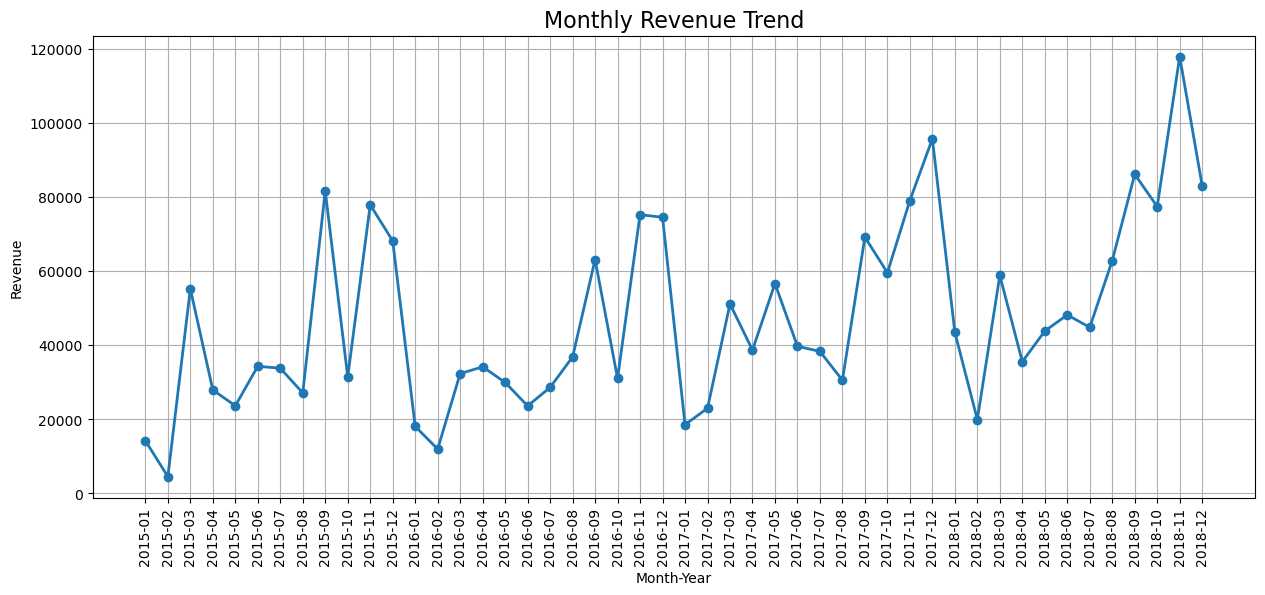

In [11]:
# 1. MONTHLY REVENUE TREND ANALYSIS
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()

# Convert Month_Year to string for plotting
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

print("\n================ MONTHLY SALES ================\n")
print(monthly_sales)

# Plot Monthly Revenue Trend
plt.figure(figsize=(15,6))
plt.plot(
    monthly_sales['Month_Year'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month-Year')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.grid(True)

# Save Graph
plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\monthly_revenue_trend.png", bbox_inches='tight')

plt.show()


================ TOP 10 SELLING PRODUCTS ================

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


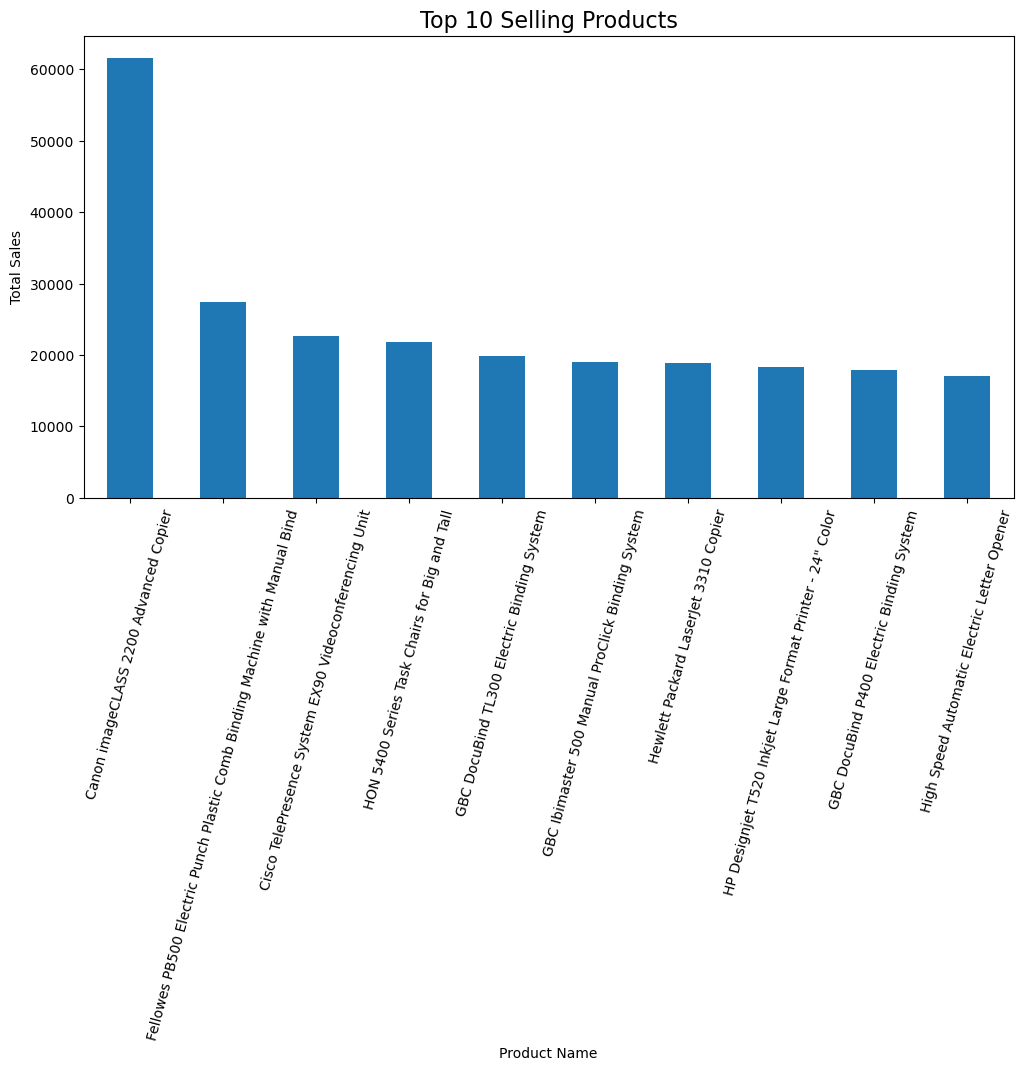

In [12]:
# 2. TOP-SELLING PRODUCTS

top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print("\n================ TOP 10 SELLING PRODUCTS ================\n")
print(top_products)

# Plot Top Products
plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title('Top 10 Selling Products', fontsize=16)
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=75)

# Save Graph
plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\top_selling_products.png", bbox_inches='tight')

plt.show()



================ TOTAL SALES ================

Total Sales : 2261536.78

================ SALES BY CATEGORY ================

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


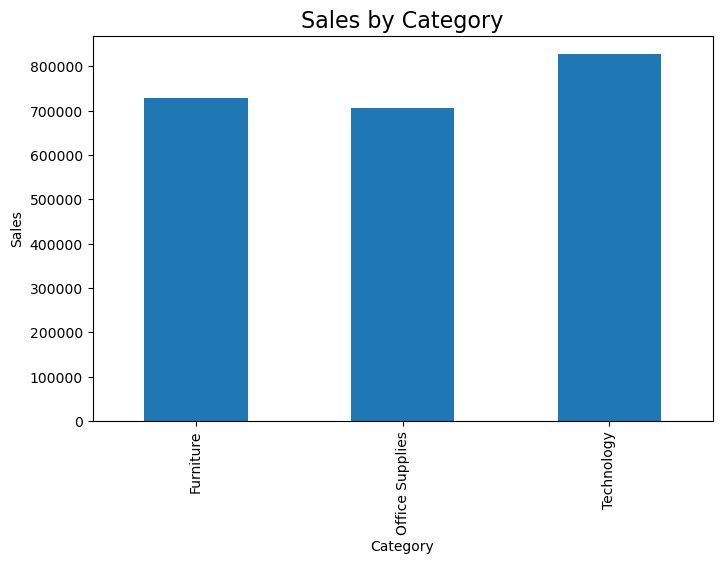

In [13]:
# 3. PROFIT ANALYSIS
# Total Sales
total_sales = df['Sales'].sum()

print("\n================ TOTAL SALES ================\n")
print("Total Sales :", round(total_sales, 2))

# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()

print("\n================ SALES BY CATEGORY ================\n")
print(category_sales)

# Plot Sales by Category
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Sales')

# Save Graph
plt.savefig("sales_by_category.png", bbox_inches='tight')

plt.show()

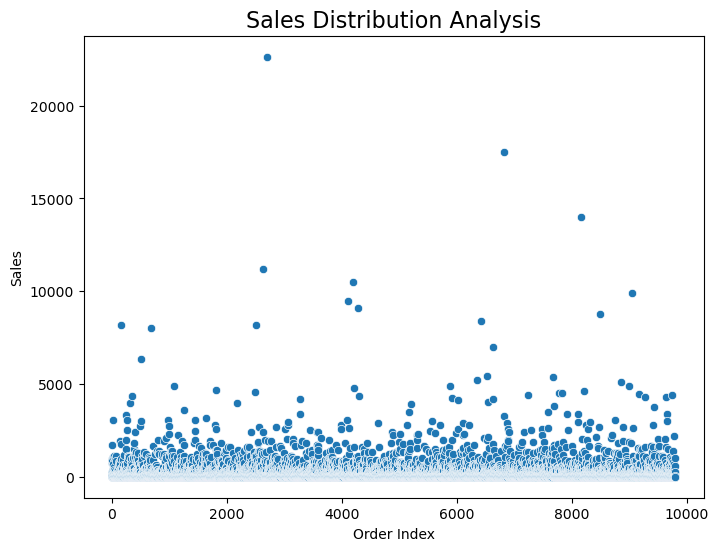

In [14]:
# 4. SALES DISTRIBUTION ANALYSIS


plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.index,
    y=df['Sales']
)

plt.title('Sales Distribution Analysis', fontsize=16)
plt.xlabel('Order Index')
plt.ylabel('Sales')

# Save Graph
plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\sales_distribution_analysis.png", bbox_inches='tight')

plt.show()


================ REGION WISE SALES ================

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


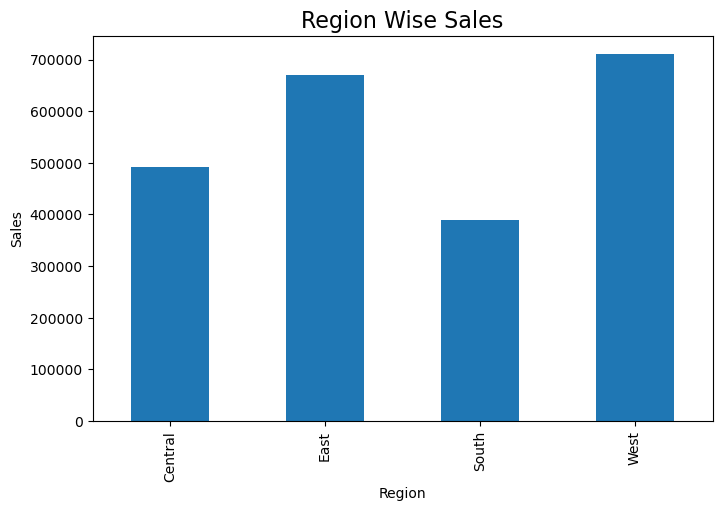

In [15]:
# 5. REGIONAL SALES ANALYSIS


region_sales = df.groupby('Region')['Sales'].sum()

print("\n================ REGION WISE SALES ================\n")
print(region_sales)

# Plot Regional Sales
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Region Wise Sales', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Sales')

# Save Graph
plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\region_wise_sales.png", bbox_inches='tight')

plt.show()

In [16]:
# 6. BUSINESS INSIGHTS

# Highest Revenue Month
highest_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax()
]

print(f"1. Highest Revenue Month : {highest_month['Month_Year']}")
print(f"   Revenue Generated     : {round(highest_month['Sales'], 2)}\n")

# Best Selling Product
best_product = top_products.idxmax()

print(f"2. Best Selling Product  : {best_product}")
print(f"   Total Sales           : {round(top_products.max(), 2)}\n")

# Highest Sales Category
highest_sales_category = category_sales.idxmax()

print(f"3. Highest Sales Category : {highest_sales_category}")
print(f"   Total Sales            : {round(category_sales.max(), 2)}\n")

# Lowest Sales Category
lowest_sales_category = category_sales.idxmin()

print(f"4. Lowest Sales Category : {lowest_sales_category}")
print(f"   Total Sales           : {round(category_sales.min(), 2)}\n")

# Highest Sales Region
top_region = region_sales.idxmax()

print(f"5. Region with Highest Sales : {top_region}")
print(f"   Total Sales               : {round(region_sales.max(), 2)}\n")


1. Highest Revenue Month : 2018-11
   Revenue Generated     : 117938.16

2. Best Selling Product  : Canon imageCLASS 2200 Advanced Copier
   Total Sales           : 61599.82

3. Highest Sales Category : Technology
   Total Sales            : 827455.87

4. Lowest Sales Category : Office Supplies
   Total Sales           : 705422.33

5. Region with Highest Sales : West
   Total Sales               : 710219.68



In [17]:
# SAVE BUSINESS INSIGHTS REPORT


insights_report = f"""
===================================================
                BUSINESS INSIGHTS
===================================================

1. Highest Revenue Month : {highest_month['Month_Year']}
   Revenue Generated     : {round(highest_month['Sales'], 2)}

2. Best Selling Product  : {best_product}
   Total Sales           : {round(top_products.max(), 2)}

3. Highest Sales Category : {highest_sales_category}
   Total Sales            : {round(category_sales.max(), 2)}

4. Lowest Sales Category : {lowest_sales_category}
   Total Sales           : {round(category_sales.min(), 2)}

5. Region with Highest Sales : {top_region}
   Total Sales               : {round(region_sales.max(), 2)}

===================================================
        ANALYSIS COMPLETED SUCCESSFULLY
===================================================
"""

# Save Insights Report
with open(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task5\Business_Insights_Report.txt", "w") as file:
    file.write(insights_report)
